# 기능 1 — 감성 분석 (Sentiment Analysis)

채팅 메시지를 **긍정(1) / 부정(0)** 두 가지로 분류하는 모델입니다.

- **데이터**: AIHub 감성대화 말뭉치 (`감정_대분류` + `사람문장1~3`)
- **라벨링**: `기쁨` → 긍정(1), 그 외 감정 → 부정(0) 의 **이진 분류**
- **모델**: KcELECTRA(딥러닝) + SVM(TF-IDF) 의 **7:3 Soft Voting 앙상블**
- **평가**: Accuracy · Macro-F1 · Confusion Matrix (Test 10%)

> **재현성**: Seed=42 / Train:Val:Test = 80:10:10 (Stratified Split)

### 전체 파이프라인
`환경설정 → 토크나이저 → 데이터 전처리·분할 → 토큰화 → 평가지표 → KcELECTRA 학습 → 분포통계 → SVM 보조모델 → 앙상블 추론·최종평가`


## 0. 환경 설정
필요한 라이브러리를 설치한다. *(Colab 기준 `!pip`)*

In [1]:
# 라이브러리 설치 (설치 후 런타임 재시작이 필요할 수 있습니다)
# 작업/실행 환경은 Google Colab 기준입니다.
!pip install -q transformers datasets evaluate accelerate torch openpyxl
# 그래프 한글 폰트 (Confusion Matrix 라벨용)
!apt-get -qq -y install fonts-nanum > /dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [2]:
# [로그 기록 시작] 이후 모든 print 출력을 콘솔과 log.txt 에 동시 기록 (재현성/적법성 증빙용)
import sys
import datetime


class _Tee:
    """stdout 출력을 콘솔과 로그 파일에 동시에 기록하는 도우미"""
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()

    def flush(self):
        for s in self.streams:
            s.flush()

    def isatty(self):
        # transformers 등 일부 라이브러리가 stdout.isatty()를 호출하므로 지원한다.
        first = self.streams[0] if self.streams else None
        fn = getattr(first, "isatty", None)
        return fn() if callable(fn) else False

    def __getattr__(self, name):
        # write/flush/isatty 외의 속성(fileno, encoding, buffer 등)은 원본 stream에 위임한다.
        return getattr(self.streams[0], name)


# 원본 stdout 보관 (셀 재실행 시 중복 래핑 방지)
if not hasattr(sys, "_orig_stdout"):
    sys._orig_stdout = sys.stdout

# log.txt 새로 쓰기 모드로 열기 (이전 실행 로그는 덮어씀)
_log_file = open("log.txt", "w", encoding="utf-8")
sys.stdout = _Tee(sys._orig_stdout, _log_file)

print("=" * 60)
print("[LOG] 기능 1 - 감성 분석(Sentiment Analysis) 실행 로그")
print(f"[LOG] 기록 시작 시각: {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")
print("[LOG] Seed=42 / Stratified 8:1:1 / 지표: Accuracy, Macro-F1, Confusion Matrix")
print("[LOG] 이후의 모든 진행 상황이 log.txt 에 기록됩니다.")
print("=" * 60)


[LOG] 기능 1 - 감성 분석(Sentiment Analysis) 실행 로그
[LOG] 기록 시작 시각: 2026-06-10 06:48:46
[LOG] Seed=42 / Stratified 8:1:1 / 지표: Accuracy, Macro-F1, Confusion Matrix
[LOG] 이후의 모든 진행 상황이 log.txt 에 기록됩니다.


## 1. 기본 설정 & 토크나이저 로드
- 사용할 사전학습 모델(**KcELECTRA**)과 하이퍼파라미터를 지정한다.
- **Seed=42** 로 난수를 고정해 재현성을 확보한다.
- GPU가 있으면 자동으로 사용한다.

In [3]:
# 기본 설정 및 Tokenizer 로드
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# [재현성] Seed=42 로 모든 난수 고정
# random / numpy / torch / transformers 시드를 한 번에 맞춰
# 학습 셔플·가중치 초기화 등을 재현 가능하게 만든다.
import random
import numpy as np
from transformers import set_seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# 모델과 하이퍼파라미터 설정
MODEL_NAME = "beomi/KcELECTRA-base-v2022"
MAX_LEN = 128
BATCH_SIZE = 16
NUM_LABELS = 2 # 분류할 클래스 개수

# 디바이스 설정 (GPU 우선)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# Tokenizer 로드
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

현재 사용 중인 디바이스: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/450k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## 2. 데이터 로드 · 전처리 · 8:1:1 분할
- AIHub 엑셀에서 필요한 컬럼만 읽어 메모리를 절약한다.
- `사람문장1~3`을 합쳐 하나의 `text`로 만든다.
- **`기쁨`→긍정(1), 그 외→부정(0)** 으로 이진 라벨링한다.
- 클래스 불균형을 막기 위해 **1:1 다운샘플링**한다.
- **Stratified Split**으로 Train 80% / Val 10% / Test 10% 로 나눈다. *(seed=42)*

> **누출 방지**: 여기서 Test를 분리해 두고, 이후 학습에는 절대 쓰지 않는다.

In [9]:
# 데이터 로드, 전처리, 8:1:1 분할
from datasets import Dataset, DatasetDict
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import gc # 메모리 청소용 라이브러리

print("원천 엑셀 데이터를 로드하고 전처리를 시작합니다...")

train_file = "감성대화말뭉치(최종데이터)_Training.xlsx"
valid_file = "감성대화말뭉치(최종데이터)_Validation.xlsx"

# 꼭 필요한 4개 컬럼만 골라 읽어 RAM 절약
target_cols = ['감정_대분류', '사람문장1', '사람문장2', '사람문장3']

train_raw = pd.read_excel(train_file, usecols=target_cols)
valid_raw = pd.read_excel(valid_file, usecols=target_cols)

# 두 데이터를 하나의 풀로 통합
aihub_raw = pd.concat([train_raw, valid_raw], ignore_index=True)

# 사용이 끝난 개별 원천 데이터는 메모리에서 즉시 삭제
del train_raw, valid_raw
gc.collect()

# 텍스트 결합 (사람문장 1, 2, 3 통합)
def combine_user_sentences(row):
    sentences = []
    if pd.notna(row['사람문장1']): sentences.append(str(row['사람문장1']).strip())
    if pd.notna(row['사람문장2']): sentences.append(str(row['사람문장2']).strip())
    if pd.notna(row['사람문장3']): sentences.append(str(row['사람문장3']).strip())
    return " ".join(sentences)

aihub_raw['text'] = aihub_raw.apply(combine_user_sentences, axis=1)

# [중복 제거] 동일 문장이 train/test 양쪽에 들어가는 누출을 막기 위해
# text 기준 중복 행을 제거한다. (Training+Validation 통합 풀에서 1회)
aihub_raw = aihub_raw.drop_duplicates(subset=["text"]).reset_index(drop=True)

# 이진 라벨링 ('기쁨' -> 1 / 그 외 -> 0)
aihub_raw['감정_대분류'] = aihub_raw['감정_대분류'].str.strip()
aihub_raw['label'] = aihub_raw['감정_대분류'].apply(lambda x: 1 if x == '기쁨' else 0)

# 데이터프레임을 해제하기 전에 개수만 미리 저장
total_raw_count = len(aihub_raw)
pos_data = aihub_raw[aihub_raw['label'] == 1]
neg_data = aihub_raw[aihub_raw['label'] == 0]

pos_count = len(pos_data)
neg_count = len(neg_data)
min_count = min(pos_count, neg_count)

# 1:1 다운샘플링
pos_balanced = pos_data.sample(n=min_count, random_state=42)
neg_balanced = neg_data.sample(n=min_count, random_state=42)

balanced_all = pd.concat([pos_balanced, neg_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)
balanced_count = len(balanced_all)

# 사용이 끝난 데이터프레임 해제
del aihub_raw, pos_data, neg_data, pos_balanced, neg_balanced
gc.collect()

# 토큰화 입력용 빈 context 컬럼 (단일 문장 분류)
balanced_all['context'] = ""

# 8:1:1 정밀 분할
train_df, temp_df = train_test_split(
    balanced_all, test_size=0.20, random_state=42, stratify=balanced_all['label']
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

# 최종 분할 개수 저장
train_count = len(train_df)
valid_count = len(valid_df)
test_count = len(test_df)

# Hugging Face DatasetDict 구조로 변환
raw_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(valid_df.reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df.reset_index(drop=True))
})

# 남은 데이터프레임 해제
del balanced_all, train_df, valid_df, test_df
gc.collect()

# 데이터 분할 결과 출력
print("\n" + "="*60)
print("[원천 엑셀 데이터 로드, 라벨링 및 8:1:1 분할 완료]")
print("="*60)
print(f" 원천 Excel 로드 총량 : {total_raw_count}개")
print(f" 원천 클래스별 분포   : 긍정(기쁨) {pos_count}개 / 부정(그 외 5종) {neg_count}개")
print(f" 1:1 다운샘플링 총량  : {balanced_count}개 (긍정: {min_count}개 / 부정: {min_count}개)")
print("-" * 60)
print(f" 훈련 데이터 (Train 80%)      : {train_count}개")
print(f" 검증 데이터 (Validation 10%) : {valid_count}개")
print(f" 평가 데이터 (Test 10%)       : {test_count}개")
print("="*60)

원천 엑셀 데이터를 로드하고 전처리를 시작합니다...

[원천 엑셀 데이터 로드, 라벨링 및 8:1:1 분할 완료]
 원천 Excel 로드 총량 : 58269개
 원천 클래스별 분포   : 긍정(기쁨) 7339개 / 부정(그 외 5종) 50930개
 1:1 다운샘플링 총량  : 14678개 (긍정: 7339개 / 부정: 7339개)
------------------------------------------------------------
 훈련 데이터 (Train 80%)      : 11742개
 검증 데이터 (Validation 10%) : 1468개
 평가 데이터 (Test 10%)       : 1468개


## 3. 토큰화
문장을 모델이 이해할 수 있는 토큰 ID로 변환한다. (최대 길이 128, 패딩/절단 적용)

In [10]:
# 토큰화 (context, text 쌍으로 변환)
def tokenize_function(examples):
    return tokenizer(
        examples["context"],
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# 데이터셋 토큰화
encoded_dataset = raw_dataset.map(tokenize_function, batched=True)
print("전처리 및 토큰화 완료")

Map:   0%|          | 0/11742 [00:00<?, ? examples/s]

Map:   0%|          | 0/1468 [00:00<?, ? examples/s]

Map:   0%|          | 0/1468 [00:00<?, ? examples/s]

전처리 및 토큰화 완료


## 4. 평가지표 설정
검증 단계에서 **Macro-F1**을 계산한다. (클래스별 F1의 평균 → 불균형에 강건)

In [11]:
# 평가지표 설정
import evaluate
import numpy as np

# Macro-F1 메트릭 로드
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # 확률값이 가장 높은 클래스의 인덱스를 추출
    predictions = np.argmax(predictions, axis=1)
    # 클래스 불균형에 강건한 macro 평균 사용
    return f1_metric.compute(predictions=predictions, references=labels, average="macro")

## 5. 모델 로드 & 학습 인자 설정
- KcELECTRA를 이진 분류용으로 불러온다.
- `load_best_model_at_end=True` → **검증(Validation) 성능 기준**으로 최적 모델을 선택한다. *(Test 미사용 → 적법)*

In [12]:
# 모델 로드 및 학습 인자 설정
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

print("모델을 다운로드하고 불러오는 중입니다...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
).to(device)

training_args = TrainingArguments(
    output_dir="./saved_models",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,   # 체크포인트 1개만 유지 (디스크 정리)
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

# Trainer 구성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset['train'],
    eval_dataset=encoded_dataset['validation'],
    compute_metrics=compute_metrics
)

print("모델 및 Trainer 세팅 완료")

모델을 다운로드하고 불러오는 중입니다...


pytorch_model.bin:   0%|          | 0.00/511M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-base-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

모델 및 Trainer 세팅 완료


## 6. 학습 & Test 평가
- **Train + Validation 으로만 학습**한다.
- 학습이 끝난 뒤 **마지막에 한 번만 Test로 성능을 측정**한다. *(테스트셋 누출 없음)*

In [1]:
# 학습 시작 및 최종 평가
print("학습을 시작합니다...")
trainer.train()

# 학습 종료 후 Test 로 최종 평가
print("Test 데이터셋 평가 진행 중...")
test_results = trainer.evaluate(encoded_dataset['test'])
print(f"Test 결과: {test_results}")

trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")
print("최종 모델 저장 완료")

학습을 시작합니다...


NameError: name 'trainer' is not defined

## 7. 데이터 분포 통계
Train/Val/Test 각각의 긍·부정 개수를 출력해 1:1 균형이 맞는지 확인한다.

In [ ]:
# 데이터 분포 통계 출력
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import warnings

# 경고 메시지 끄기
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150

# 데이터셋 분포 텍스트 출력
train_labels = raw_dataset['train']['label']
valid_labels = raw_dataset['validation']['label']
test_labels = raw_dataset['test']['label']

print("="*60)
print("[AIHub 감성 데이터셋 분포 통계]")
print("="*60)
# 0과 1의 개수를 센다
print(f"Train (학습용) : 총 {len(train_labels):,}개 / 긍정(1) {train_labels.count(1):,}개 / 부정(0) {train_labels.count(0):,}개")
print(f"Valid (검증용) : 총 {len(valid_labels):,}개 / 긍정(1) {valid_labels.count(1):,}개 / 부정(0) {valid_labels.count(0):,}개")
print(f"Test  (평가용) : 총 {len(test_labels):,}개 / 긍정(1) {test_labels.count(1):,}개 / 부정(0) {test_labels.count(0):,}개")
print("-" * 60)
print("클래스 불균형 방지를 위해 1:1 비율로 맞춘다.")
print("="*60)


[AIHub 감성 데이터셋 분포 통계]
Train (학습용) : 총 11,742개 / 긍정(1) 5,871개 / 부정(0) 5,871개
Valid (검증용) : 총 1,468개 / 긍정(1) 734개 / 부정(0) 734개
Test  (평가용) : 총 1,468개 / 긍정(1) 734개 / 부정(0) 734개
------------------------------------------------------------
클래스 불균형 방지를 위해 1:1 비율로 맞춘다.


## 8. SVM 보조 모델 학습
- TF-IDF로 텍스트를 벡터화하고 **SVM**을 학습한다.
- 벡터라이저·SVM 모두 **Train 데이터로만 fit** 한다. *(누출 없음)*
- KcELECTRA와 앙상블하기 위한 보조 모델이다.

In [ ]:
# SVM 모델용 결합 텍스트 벡터화 및 학습
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

print("SVM 모델 학습 중...")
X_train_text = [row['text'] for row in raw_dataset['train']]
y_train_labels = raw_dataset['train']['label']

vectorizer = TfidfVectorizer(max_features=5000)
X_train_svm = vectorizer.fit_transform(X_train_text)

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_svm, y_train_labels)
print("SVM 모델 학습 완료!")

SVM 모델 학습 중...
SVM 모델 학습 완료!


## 9. 7:3 앙상블 추론 & 최종 평가
- 각 Test 문장에 대해 **KcELECTRA(0.7) + SVM(0.3)** 확률을 가중 합산해 최종 예측한다.
- **Accuracy · Macro-F1 · Confusion Matrix** 와 예시 10개를 출력한다. (기능1의 최종 성능)

테스트 데이터셋에 대한 앙상블 추론을 시작합니다...


모델 평가 중: 100%|██████████| 1468/1468 [00:17<00:00, 82.03it/s]


[최종 하이브리드 모델 평가]
              precision    recall  f1-score   support

       부정(0)     0.9651    0.9782    0.9716       734
       긍정(1)     0.9779    0.9646    0.9712       734

    accuracy                         0.9714      1468
   macro avg     0.9715    0.9714    0.9714      1468
weighted avg     0.9715    0.9714    0.9714      1468


[예시 문장 10개 판별 결과]
[1번 문장]
 발화(Text)   : 예절교육 때문에 방학때 성당캠프에 와있는데 가족이 너무 그리워. 혼자 떨어져서 있으니까 외롭다. 매년 참석하고 있어. 올때마다 가족의 소중함을 느끼는데 이젠 소중함을 넘어서 고립된 느낌이야.
 예측 결과    : 부정(0) (확신도: 긍정 0.5% / 부정 99.5%)


 실제 정답    : 부정(0)
--------------------------------------------------
[2번 문장]
 발화(Text)   : 따돌림을 당하지 않게 도와준 친구가 많아서 감사해. 친구들이 먼저 다가와줬어. 얼마나 고마운지 몰라.
 예측 결과    : 긍정(1) (확신도: 긍정 100.0% / 부정 0.0%)
 실제 정답    : 긍정(1)
--------------------------------------------------
[3번 문장]
 발화(Text)   : 회사에서 중요한 업무를 맡았는데 나 때문에 망쳐버렸어. 어떡하지. 거래처와 약속을 했는데 내 실수로 미팅 날짜를 놓쳤어. 상사가 내 실수니까 알아서 하라고 말하고 연락을 받지 않아. 우선 전화로 죄송하다고 말씀드리고 다시 미팅날짜를 잡았어. 내일 회사에 가서 상사에게 보고할 예정이야.
 예측 결과    : 부정(0) (확신도: 긍정 0.2% / 부정 99.8%)
 실제 정답    : 부정(0)
--------------------------------------------------
[4번 문장]
 발화(Text)   : 나 드디어 원하는 직장에 취직했어. 너무 기분이 좋고 신이 나. 이제부터 시작이니 더욱 노력해야겠어.
 예측 결과    : 긍정(1) (확신도: 긍정 100.0% / 부정 0.0%)
 실제 정답    : 긍정(1)
--------------------------------------------------
[5번 문장]
 발화(Text)   : 정말 나쁜 일이 벌어지는 것을 봤어. 그래서 기분이 좋지 않아. 회사 직원 중 한 명이 사장에게만 잘하고 동료들을 무시하는 행위가 너무 잘못돼 보여. 사장 이외의 나이 든 직장 상사 분들이 있는데 사장 앞에만 수저와 젓가락을 놔 주고 다른 분들의 것은 신경을 쓰지 않는 직원이 있었어. 그 행동이 불쾌했어.
 예측 결과    : 부정(0) (확신도: 긍정 0.9% / 부정 99.1%)
 실제 정답    :

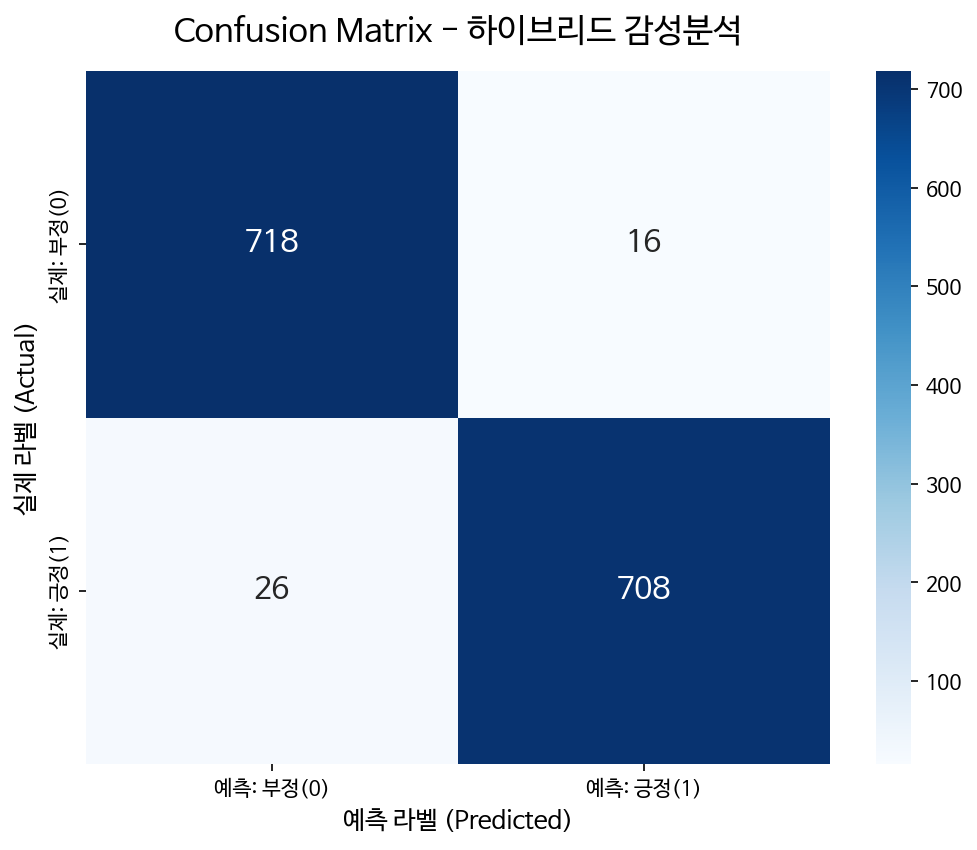

In [ ]:
# 7:3 앙상블 추론 및 최종 평가 (예시 10개 포함)
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import numpy as np

print("테스트 데이터셋에 대한 앙상블 추론을 시작합니다...")

test_df = pd.DataFrame(raw_dataset['test'])
y_true = []
y_pred = []
probs_list = []

model.eval()

# 모델 평가 루프
for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="모델 평가 중"):
    txt = str(row['text'])
    true_label = int(row['label'])

    # 1. KcELECTRA 추론
    inputs = tokenizer(txt, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        kc_probs = F.softmax(model(**inputs).logits, dim=-1).cpu().numpy()[0]

    # 2. SVM 추론
    svm_probs = svm_model.predict_proba(vectorizer.transform([txt]))[0]

    # 3. 7:3 가중 앙상블
    prob_pos = (kc_probs[1] * 0.7) + (svm_probs[1] * 0.3)
    prob_neg = (kc_probs[0] * 0.7) + (svm_probs[0] * 0.3)

    final_pred = 1 if prob_pos > prob_neg else 0

    y_true.append(true_label)
    y_pred.append(final_pred)
    # 예시 출력을 위해 확률 저장
    probs_list.append((prob_neg, prob_pos))

# 결과 1: 전체 평가 지표
print("\n" + "="*60)
print("[최종 하이브리드 모델 평가]")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['부정(0)', '긍정(1)'], digits=4))

# 결과 2: 예시 문장 10개
print("\n" + "="*60)
print("[예시 문장 10개 판별 결과]")
print("="*60)
label_map = {0: "부정(0)", 1: "긍정(1)"}

# 앞에서부터 10개 출력
for i in range(10):
    print(f"[{i+1}번 문장]")
    print(f" 발화(Text)   : {test_df['text'][i]}")
    print(f" 예측 결과    : {label_map[y_pred[i]]} (확신도: 긍정 {probs_list[i][1]*100:.1f}% / 부정 {probs_list[i][0]*100:.1f}%)")
    print(f" 실제 정답    : {label_map[y_true[i]]}")
    print("-" * 50)

# 결과 3: Confusion Matrix (한글 폰트 등록 — 설치는 최상단 환경설정 셀에서 완료)
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum/']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files: fm.fontManager.addfont(font_file)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측: 부정(0)', '예측: 긍정(1)'],
            yticklabels=['실제: 부정(0)', '실제: 긍정(1)'],
            annot_kws={"size": 15})
plt.title('Confusion Matrix - 하이브리드 감성분석', fontsize=16, pad=15)
plt.xlabel('예측 라벨 (Predicted)', fontsize=12)
plt.ylabel('실제 라벨 (Actual)', fontsize=12)
plt.savefig('confusion_matrix_sentiment_only.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# [로그 기록 종료] log.txt 마무리 및 파일 닫기 (모든 셀 실행 후 마지막에 1회 실행)
import sys
import datetime

print("=" * 60)
print(f"[LOG] 기록 종료 시각: {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")
print("[LOG] 모든 실행이 정상적으로 완료되었습니다.")
print("=" * 60)

# stdout 을 원래대로 복구하고 로그 파일을 안전하게 닫는다
if hasattr(sys, "_orig_stdout"):
    sys.stdout = sys._orig_stdout
try:
    _log_file.close()
except Exception:
    pass

print("[System] 'log.txt' 저장 완료!")


[LOG] 기록 종료 시각: 2026-06-08 10:47:10
[LOG] 모든 실행이 정상적으로 완료되었습니다.
[System] 'log.txt' 저장 완료!


## 10. 구글 드라이브에 저장 (기능 3 연동용)

기능 1의 모든 산출물을 **내 드라이브의 `MyDrive/feature1/` 한 폴더**에 모아 저장합니다.
기능 1·2·3을 각각 다른 Colab 세션에서 실행하므로, 공유 저장소인 드라이브에 저장해야 기능 3이 연동됩니다.
**런타임을 닫기 전에 이 셀을 실행하세요.** (`svm_model`·`vectorizer`는 메모리에만 있어, 닫으면 사라집니다.)

`MyDrive/feature1/` 에 저장되는 것:
- `chaeon_feature1_checkpoint/` ← KcELECTRA 모델 + 토크나이저
- `svm_model.pkl` ← SVM 모델
- `vectorizer.pkl` ← TF-IDF 벡터라이저
- `result.txt` ← Test 기준 최종 지표(Accuracy·Macro-F1 등) **자동 생성**
- `log.txt` ← 실행 로그 (작업폴더에서 복사)

> 기능 3 통합 노트북은 이 `MyDrive/feature1/` 경로에서 모델을 불러옵니다.

In [ ]:
# [기능 3 연동 + 산출물 정리] 학습 결과·result·log 를 MyDrive/feature1/ 한 폴더에 모아 저장
import os, shutil, joblib, datetime
from google.colab import drive
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

drive.mount('/content/drive')
F1_DIR = '/content/drive/MyDrive/feature1'   # 기능1 산출물 전용 폴더 (모델+result+log 한 곳)
os.makedirs(F1_DIR, exist_ok=True)

# 1) KcELECTRA 최종 모델 + 토크나이저 -> feature1 폴더
dst = os.path.join(F1_DIR, 'chaeon_feature1_checkpoint')
trainer.save_model(dst)            # model.safetensors + config 직접 기록
tokenizer.save_pretrained(dst)
print('[저장] KcELECTRA 체크포인트 ->', dst)

# 2) SVM + 3) TF-IDF 벡터라이저 -> feature1 폴더
joblib.dump(svm_model,  os.path.join(F1_DIR, 'svm_model.pkl'))
joblib.dump(vectorizer, os.path.join(F1_DIR, 'vectorizer.pkl'))
print('[저장] svm_model.pkl / vectorizer.pkl ->', F1_DIR)

# 4) result.txt 자동 생성 — Test(y_true/y_pred, 앞 평가 셀에서 계산) 기준 최종 지표
#    (모델 저장이 우선이므로, 지표 계산이 실패해도 저장은 유지되도록 try 로 감싼다)
try:
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    rep = classification_report(y_true, y_pred, target_names=['부정(0)', '긍정(1)'], digits=4, output_dict=True)
    cm  = confusion_matrix(y_true, y_pred)
    result_text = "\n".join([
        "=" * 60,
        "[기능 1 - 감성 분석 (Sentiment Analysis)] 재현성 & 결과",
        "=" * 60,
        "",
        "[데이터셋]",
        "- 출처   : AIHub 감성대화 말뭉치 (감정_대분류 + 사람문장1~3)",
        "- 라벨링 : 기쁨 -> 긍정(1) / 그 외 감정 -> 부정(0)  (이진 분류)",
        f"- 분할   : Stratified 80:10:10  (Train {train_count} / Val {valid_count} / Test {test_count})",
        "",
        "[재현성]",
        "- Seed : 42  (random / numpy / torch / transformers 고정)",
        "",
        "[모델]",
        "- KcELECTRA (beomi/KcELECTRA-base-v2022) 0.7 + SVM(TF-IDF, max_features=5000) 0.3",
        "- 결합 : Soft Voting Ensemble (7:3)",
        "",
        f"[최종 성능] (Test {test_count}개)",
        f"- Accuracy : {acc:.4f}",
        f"- Macro-F1 : {mf1:.4f}",
        f"- 부정(0)  : precision {rep['부정(0)']['precision']:.4f} / recall {rep['부정(0)']['recall']:.4f} / f1 {rep['부정(0)']['f1-score']:.4f}",
        f"- 긍정(1)  : precision {rep['긍정(1)']['precision']:.4f} / recall {rep['긍정(1)']['recall']:.4f} / f1 {rep['긍정(1)']['f1-score']:.4f}",
        f"- Confusion Matrix(행=실제,열=예측) : {cm.tolist()}  (이미지: confusion_matrix_sentiment_only.png)",
        "",
        "[적법성 확인]",
        "- 학습  : Train + Validation 만 사용 (load_best_model_at_end=True, Validation 기준 선택)",
        "- 테스트 : 학습 종료 후 Test 로 1회만 측정 (테스트셋 누출 없음)",
        f"- 기록 시각 : {datetime.datetime.now():%Y-%m-%d %H:%M:%S}",
        "",
    ])
    for path in ("result.txt", os.path.join(F1_DIR, "result.txt")):
        with open(path, "w", encoding="utf-8") as f:
            f.write(result_text)
    print('[저장] result.txt -> 작업폴더 및', F1_DIR)
except NameError:
    print('[건너뜀] result.txt — y_true/y_pred 가 없습니다. 최종 평가 셀을 먼저 실행하세요.')

# 5) log.txt 를 같은 폴더로 복사 (로그 종료 셀에서 이미 작성·닫힘)
if os.path.exists("log.txt"):
    shutil.copy("log.txt", os.path.join(F1_DIR, "log.txt"))
    print('[저장] log.txt ->', F1_DIR)

# 6) Confusion Matrix 이미지도 같은 폴더로 (있으면)
if os.path.exists("confusion_matrix_sentiment_only.png"):
    shutil.copy("confusion_matrix_sentiment_only.png", os.path.join(F1_DIR, "confusion_matrix_sentiment_only.png"))

# 7) 저장 검증 — 기능 3에서 그대로 불러올 수 있는지 확인
weights_ok = any(os.path.exists(os.path.join(dst, w)) for w in ['model.safetensors', 'pytorch_model.bin'])
pkl_ok = all(os.path.exists(os.path.join(F1_DIR, f)) for f in ['svm_model.pkl', 'vectorizer.pkl'])
assert weights_ok, '[실패] 모델 가중치가 ' + dst + ' 에 없습니다. trainer.train() 이 정상 완료됐는지 확인하세요.'
assert pkl_ok, '[실패] svm_model.pkl / vectorizer.pkl 저장 실패.'
print('[검증 완료] 기능 1 산출물(모델+result+log) 저장 OK ->', F1_DIR)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[저장] KcELECTRA 체크포인트 -> /content/drive/MyDrive/feature1/chaeon_feature1_checkpoint
[저장] svm_model.pkl / vectorizer.pkl -> /content/drive/MyDrive/feature1
[저장] result.txt -> 작업폴더 및 /content/drive/MyDrive/feature1
[저장] log.txt -> /content/drive/MyDrive/feature1
[검증 완료] 기능 1 산출물(모델+result+log) 저장 OK -> /content/drive/MyDrive/feature1
